# Preguntas del taller 3

1. Hacer un programa que cargue una imagen en escala de
grises y produzca otra equalizada haciendo uso de la función
de ecualización brindada por el lenguaje utilizado.

2. Produzca una imagen comparativa entre los histogramas de
las imágenes del punto anterior.

3. Aplicar una fórmula de ecualización para oscurecer la imagen
original, oscureciendo los pixels en una tercera parte. Debe
generar la imagen ecualizada y el histograma
correspondiente.

4. Aplicar una fórmula de ecualización para aclarar la imagen
original (por lo menos en un 30%). Debe generar la imagen
ecualizada y el histograma correspondiente.

5. Aplicar una fórmula de ecualización para lograr un contraste
bajo en la imagen original. Debe generar la imagen ecualizada y
el histograma correspondiente.

6. Aplicar una fórmula de ecualización para lograr un contraste
alto en la imagen original. Debe generar la imagen ecualizada y
el histograma correspondiente.

7. Aplicar una fórmula de ecualización lineal o no lineal en una
imagen a color para cada una de las capas de la imagen. Debe
mostrar la imagen original, la ecualizada y para cada capa la
imagen y el histograma correspondiente.

In [62]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
os.makedirs("resultados", exist_ok=True)

1. Hacer un programa que cargue una imagen en escala de
grises y produzca otra equalizada haciendo uso de la función
de ecualización brindada por el lenguaje utilizado.

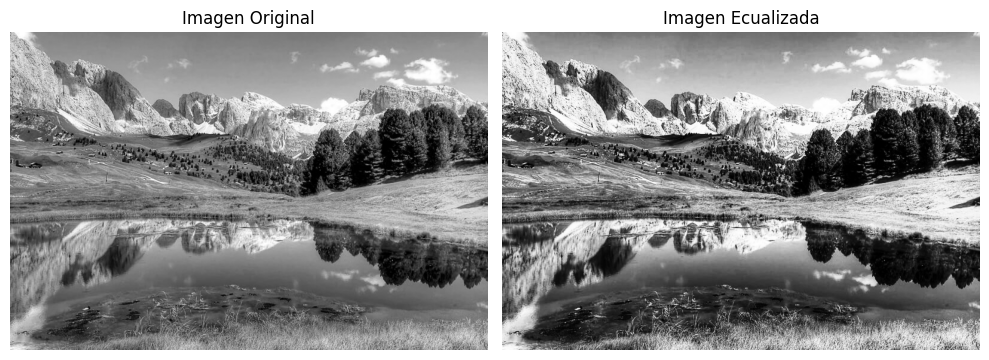

In [63]:
imagen_gris = cv2.imread("images/paisaje.png", cv2.IMREAD_GRAYSCALE)

# Imagen ecualizada utilizando OpenCV
imagen_ecualizada = cv2.equalizeHist(imagen_gris)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(imagen_gris, cmap="gray")
axes[0].set_title("Imagen Original")
axes[0].axis("off")

axes[1].imshow(imagen_ecualizada, cmap="gray")
axes[1].set_title("Imagen Ecualizada")
axes[1].axis("off")

plt.tight_layout()
plt.show()

fig.savefig("resultados/imagen_ecualizada.png")


2. Produzca una imagen comparativa entre los histogramas de
las imágenes del punto anterior.

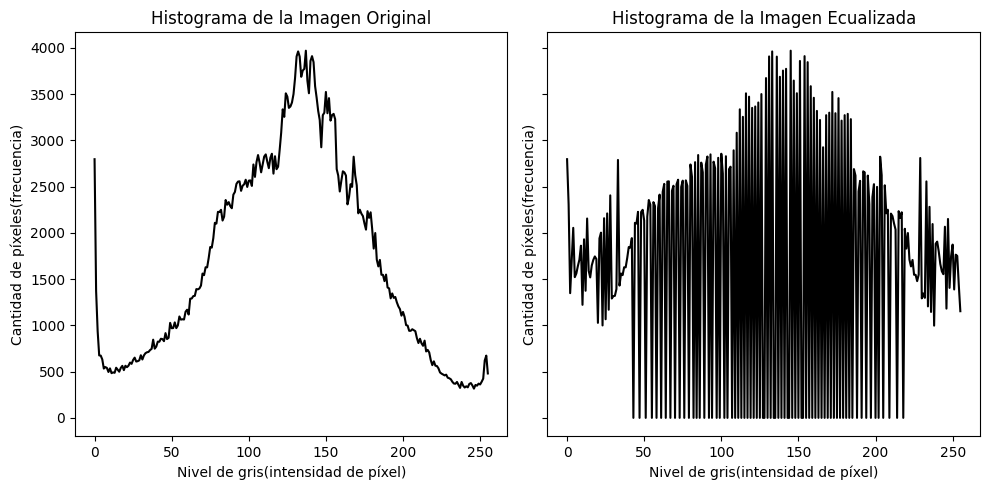

Intensidad mínima original: 0
Intensidad máxima original: 255
Intensidad mínima ecualizada: 0
Intensidad máxima ecualizada: 255
Promedio original: 126.18277204502814
Promedio ecualizado: 127.32627110694183


In [64]:
#histogramas
histograma_original = cv2.calcHist([imagen_gris], [0], None, [256], [0, 256])
histograma_ecualizado = cv2.calcHist([imagen_ecualizada], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
axes[0].plot(histograma_original, color="black")
axes[0].set_title("Histograma de la Imagen Original")
axes[0].set_xlabel("Nivel de gris(intensidad de píxel)")
axes[0].set_ylabel("Cantidad de píxeles(frecuencia)")

axes[1].plot(histograma_ecualizado, color="black")
axes[1].set_title("Histograma de la Imagen Ecualizada")
axes[1].set_xlabel("Nivel de gris(intensidad de píxel)")
axes[1].set_ylabel("Cantidad de píxeles(frecuencia)")

plt.tight_layout()
plt.show()
fig.savefig("resultados/histogramas_ecualizados.png")

print(
    "Intensidad mínima original:",
    imagen_gris.min()
)

print(
    "Intensidad máxima original:",
    imagen_gris.max()
)

print(
    "Intensidad mínima ecualizada:",
    imagen_ecualizada.min()
)

print(
    "Intensidad máxima ecualizada:",
    imagen_ecualizada.max()
)

print(
    "Promedio original:",
    imagen_gris.mean()
)

print(
    "Promedio ecualizado:",
    imagen_ecualizada.mean()
)

3. Aplicar una fórmula de ecualización para oscurecer la imagen
original, oscureciendo los pixels en una tercera parte. Debe
generar la imagen ecualizada y el histograma
correspondiente.

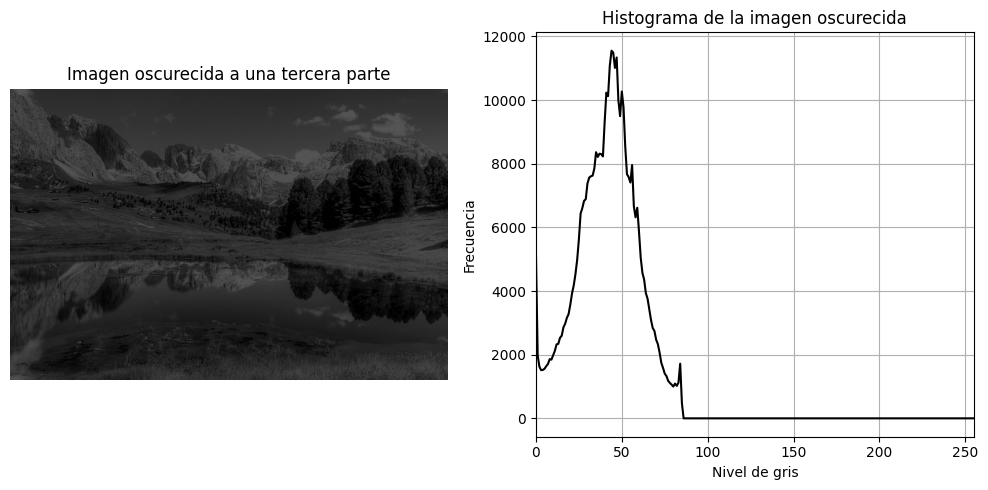

Mínimo original: 0
Máximo original: 255
Promedio original: 126.18277204502814
Mínimo oscurecida: 0
Máximo oscurecida: 85
Promedio oscurecida: 41.72897514071295


In [65]:
# Fórmula para reducir la intensidad a una tercera parte: y = x / 3
filas, columnas = imagen_gris.shape
imagen_oscura = imagen_gris.copy()

for fila in range(filas):
    for columna in range(columnas):
        pixel_original = int(imagen_gris[fila, columna])
        pixel_ecualizado = pixel_original // 3
        imagen_oscura[fila, columna] = pixel_ecualizado

histograma_oscuro = cv2.calcHist(
    [imagen_oscura],
    [0],
    None,
    [256],
    [0, 256]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Se conserva la misma escala para que el oscurecimiento sea visible.
axes[0].imshow(imagen_oscura, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Imagen oscurecida a una tercera parte")
axes[0].axis("off")

axes[1].plot(histograma_oscuro, color="black")
axes[1].set_title("Histograma de la imagen oscurecida")
axes[1].set_xlabel("Nivel de gris")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xlim(0, 255)
axes[1].grid()

plt.tight_layout()
fig.savefig("resultados/imagen_oscurecida_pt3.png")
plt.show()

print("Mínimo original:", imagen_gris.min())
print("Máximo original:", imagen_gris.max())
print("Promedio original:", imagen_gris.mean())
print("Mínimo oscurecida:", imagen_oscura.min())
print("Máximo oscurecida:", imagen_oscura.max())
print("Promedio oscurecida:", imagen_oscura.mean())

4. Aplicar una fórmula de ecualización para aclarar la imagen
original (por lo menos en un 30%). Debe generar la imagen
ecualizada y el histograma correspondiente.

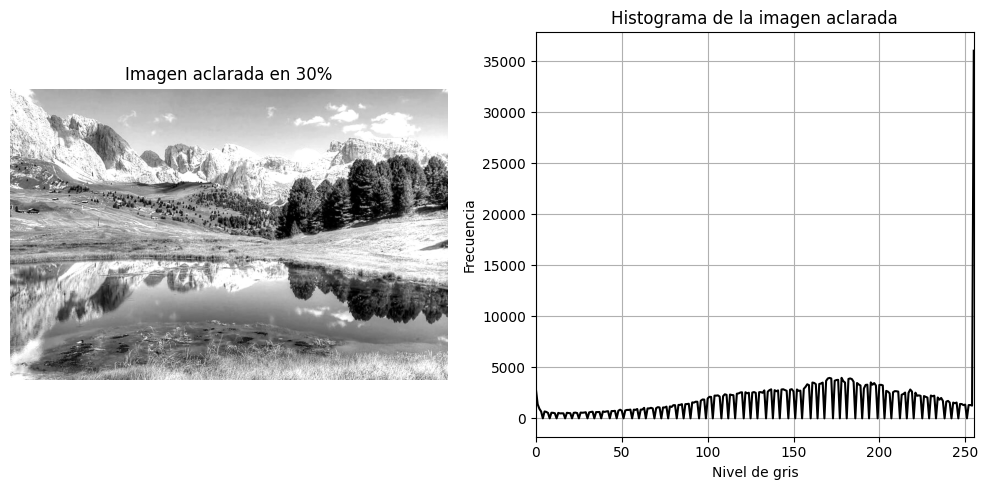

Mínimo original: 0
Máximo original: 255
Promedio original: 126.18277204502814
Mínimo aclarada: 0
Máximo aclarada: 255
Promedio aclarada: 161.0591533771107


In [66]:
# Metodo usando numpy para aclarar la imagen a una tercera parte
#metodo clip recibe (arreglo, valor minimo, valor maximo) y devuelve un arreglo con los valores que se encuentran entre el valor minimo y maximo
imagen_clara = np.clip(imagen_gris *1.3,0,255).astype(np.uint8)

histograma_claro = cv2.calcHist(
    [imagen_clara],
    [0],
    None,
    [256],
    [0, 256]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# vmin y vmax se usan para establecer el rango de valores que se mapean a la escala de grises. En este caso, se establece un rango de 0 a 255 para que la imagen aclarada se muestre correctamente en escala de grises. Esto es importante porque si no se establece un rango adecuado, la imagen podría aparecer demasiado oscura o demasiado clara, lo que dificultaría la visualización de los detalles.
axes[0].imshow(imagen_clara, cmap="gray",vmin=0, vmax=255)
axes[0].set_title("Imagen aclarada en 30%")
axes[0].axis("off")

axes[1].plot(histograma_claro, color="black")
axes[1].set_title("Histograma de la imagen aclarada")
axes[1].set_xlabel("Nivel de gris")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xlim(0, 255)
axes[1].grid()

plt.tight_layout()
fig.savefig("resultados/imagen_aclarada_pt4.png")
plt.show()

print("Mínimo original:", imagen_gris.min())
print("Máximo original:", imagen_gris.max())
print("Promedio original:", imagen_gris.mean())

print("Mínimo aclarada:", imagen_clara.min())
print("Máximo aclarada:", imagen_clara.max())
print("Promedio aclarada:", imagen_clara.mean())


5. Aplicar una fórmula de ecualización para lograr un contraste
bajo en la imagen original. Debe generar la imagen ecualizada y
el histograma correspondiente.

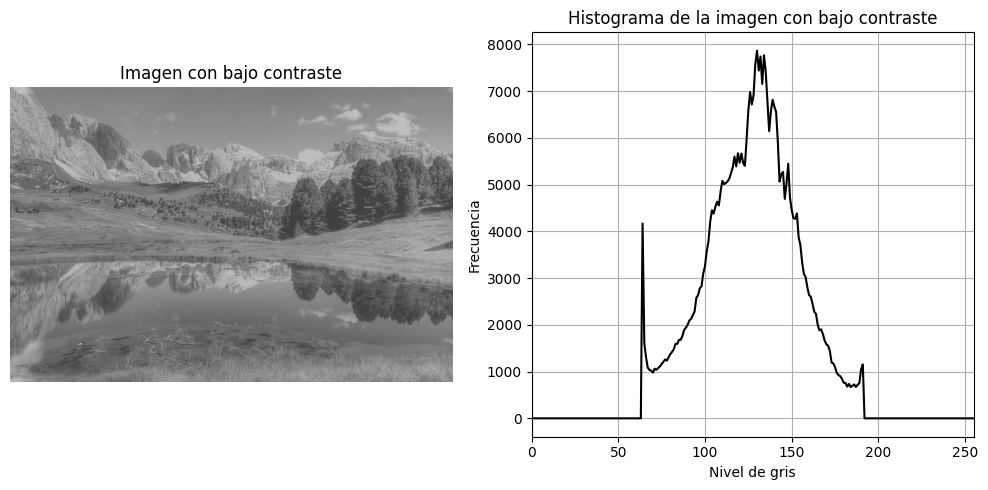

Mínimo original: 0
Máximo original: 255
Promedio original: 126.18277204502814
Mínimo bajo contraste: 64
Máximo bajo contraste: 191
Promedio bajo contraste: 126.84330675422139


In [67]:
# Se quiere un contraste mas bajo
# Para esto podemos aplicar y=0.5x + 64, este limita el rango de valores a [64, 191], lo que significa que los píxeles más oscuros se vuelven más claros y los píxeles más claros se vuelven más oscuros, pero sin llegar a los extremos de la escala de grises.

imagen_bajo_contraste = np.clip(imagen_gris * 0.5 + 64,0,255).astype(np.uint8)

histograma_bajo_contraste = cv2.calcHist([imagen_bajo_contraste], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(imagen_bajo_contraste, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Imagen con bajo contraste")
axes[0].axis("off")

axes[1].plot( histograma_bajo_contraste,color="black")
axes[1].set_title("Histograma de la imagen con bajo contraste")
axes[1].set_xlabel("Nivel de gris")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xlim(0, 255)
axes[1].grid()

plt.tight_layout()
fig.savefig("resultados/imagen_bajo_contraste_pt5.png")
plt.show()

print("Mínimo original:", imagen_gris.min())
print("Máximo original:", imagen_gris.max())
print("Promedio original:", imagen_gris.mean())
print("Mínimo bajo contraste:", imagen_bajo_contraste.min())
print("Máximo bajo contraste:", imagen_bajo_contraste.max())
print("Promedio bajo contraste:", imagen_bajo_contraste.mean())

6. Aplicar una fórmula de ecualización para lograr un contraste
alto en la imagen original. Debe generar la imagen ecualizada y
el histograma correspondiente.


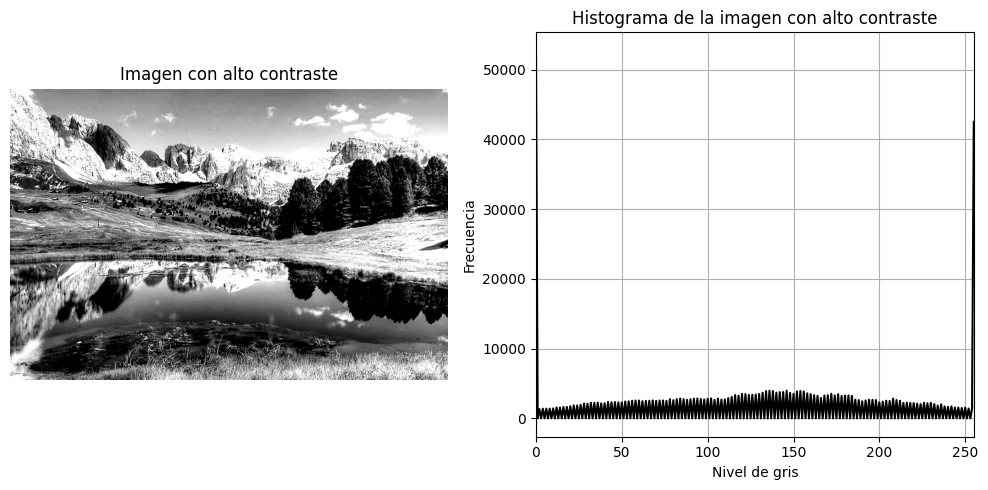

Mínimo original: 0
Máximo original: 255
Promedio original: 126.18277204502814
Mínimo alto contraste: 0
Máximo alto contraste: 255
Promedio alto contraste: 126.7728212945591


In [68]:
# Aumentar contraste
# Para ello se puede aplicar formula y = 2x - 128 este limita el rango de valores a [-128, 255], lo que significa que los píxeles más oscuros se vuelven más oscuros y los píxeles más claros se vuelven más claros, aumentando así el contraste de la imagen.

#Como se maneja negativos, se utiliza int16 para evitar el desbordamiento de enteros sin signo, y luego se utiliza np.clip para limitar los valores a [0, 255] antes de convertirlos de nuevo a uint8.
imagen_alto_contraste = np.clip(imagen_gris.astype(np.int16)*2 - 128,0,255).astype(np.uint8)
histograma_alto_contraste = cv2.calcHist([imagen_alto_contraste], [0], None, [256], [0, 256])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(imagen_alto_contraste, cmap="gray",vmin=0, vmax=255)
axes[0].set_title("Imagen con alto contraste")
axes[0].axis("off")

axes[1].plot(
    histograma_alto_contraste,
    color="black"
)

axes[1].set_title(
    "Histograma de la imagen con alto contraste"
)

axes[1].set_xlabel("Nivel de gris")
axes[1].set_ylabel("Frecuencia")
axes[1].set_xlim(0, 255)
axes[1].grid()

plt.tight_layout()
fig.savefig("resultados/imagen_alto_contraste_pt6.png")
plt.show()

print("Mínimo original:", imagen_gris.min())
print("Máximo original:", imagen_gris.max())
print("Promedio original:", imagen_gris.mean())
print("Mínimo alto contraste:", imagen_alto_contraste.min())
print("Máximo alto contraste:", imagen_alto_contraste.max())
print("Promedio alto contraste:", imagen_alto_contraste.mean())

7. Aplicar una fórmula de ecualización lineal o no lineal en una
imagen a color para cada una de las capas de la imagen. Debe
mostrar la imagen original, la ecualizada y para cada capa la
imagen y el histograma correspondiente.


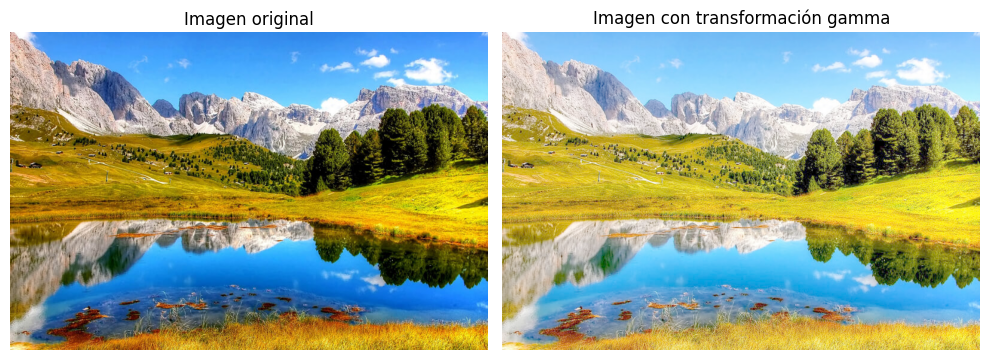

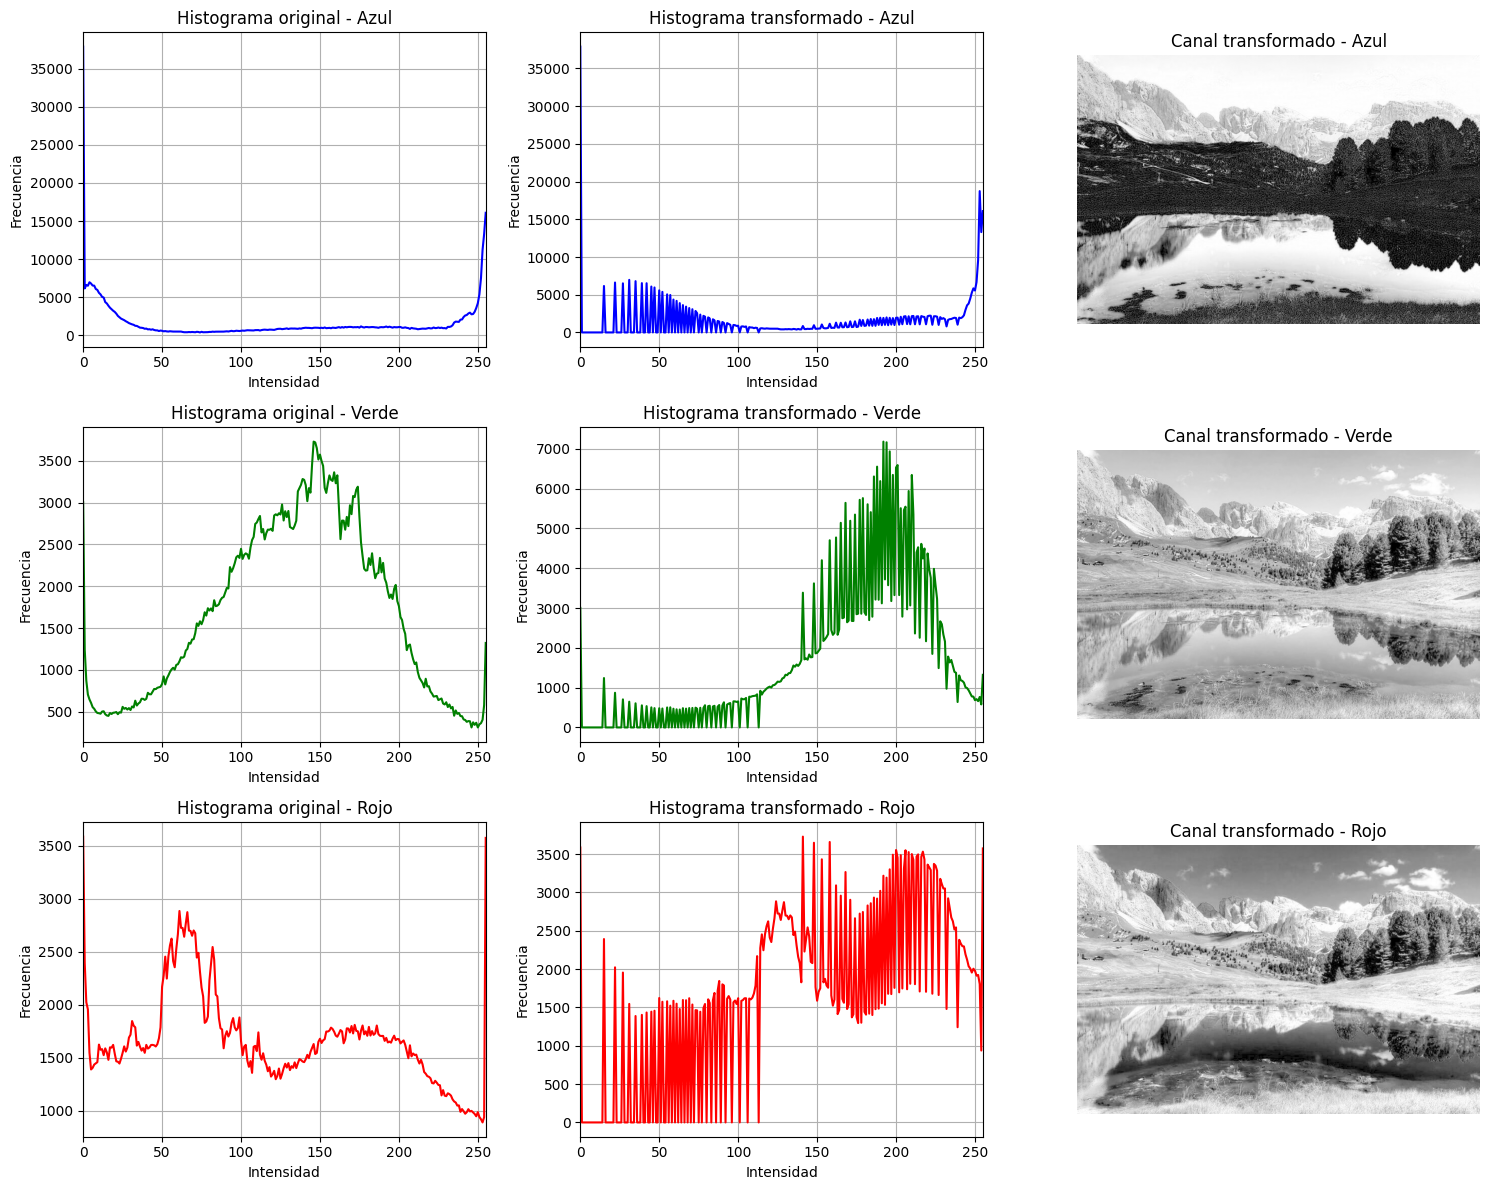

In [ ]:
# Aplico transformación no lineal de intensidad mediante corrección gamma.
# La forma general es y = c*x^gamma.
# Al normalizar x al intervalo [0,1], aplicamos yn = xn^gamma.
# Después multiplicamos por 255 para regresar al rango [0,255],
# por lo que el factor de escala queda incorporado en el procedimiento.

gamma = 0.5

# Cargar la imagen original en formato BGR
imagen_color = cv2.imread("images/paisaje.png", cv2.IMREAD_COLOR)

# Normalizar, aplicar la transformación gamma y volver al rango [0, 255]
imagen_normalizada = imagen_color / 255.0
imagen_gamma = 255 * (imagen_normalizada ** gamma)
imagen_gamma = np.clip(imagen_gamma, 0, 255).astype(np.uint8)

# Convertir de BGR a RGB para mostrar las imágenes a color con Matplotlib
imagen_color_rgb = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)
imagen_gamma_rgb = cv2.cvtColor(imagen_gamma, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(imagen_color_rgb)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(imagen_gamma_rgb)
axes[1].set_title("Imagen con transformación gamma")
axes[1].axis("off")

plt.tight_layout()
fig.savefig("resultados/gamma_color_pt7.png")
plt.show()

# Separar los canales originales y transformados
blue_original = imagen_color[:, :, 0]
green_original = imagen_color[:, :, 1]
red_original = imagen_color[:, :, 2]

blue_transformado = imagen_gamma[:, :, 0]
green_transformado = imagen_gamma[:, :, 1]
red_transformado = imagen_gamma[:, :, 2]

# Calcular los histogramas de cada canal
hist_blue_original = cv2.calcHist([blue_original], [0], None, [256], [0, 256])
hist_green_original = cv2.calcHist([green_original], [0], None, [256], [0, 256])
hist_red_original = cv2.calcHist([red_original], [0], None, [256], [0, 256])

hist_blue_transformado = cv2.calcHist([blue_transformado], [0], None, [256], [0, 256])
hist_green_transformado = cv2.calcHist([green_transformado], [0], None, [256], [0, 256])
hist_red_transformado = cv2.calcHist([red_transformado], [0], None, [256], [0, 256])

# Cada fila corresponde a un canal y cada columna a una representación
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

canales = [
    ("Azul", blue_transformado, hist_blue_original, hist_blue_transformado, "blue"),
    ("Verde", green_transformado, hist_green_original, hist_green_transformado, "green"),
    ("Rojo", red_transformado, hist_red_original, hist_red_transformado, "red")
]

for fila, (nombre, canal_transformado, hist_original, hist_transformado, color) in enumerate(canales):
    axes[fila, 0].plot(hist_original, color=color)
    axes[fila, 0].set_title(f"Histograma original - {nombre}")
    axes[fila, 0].set_xlim(0, 255)
    axes[fila, 0].set_xlabel("Intensidad")
    axes[fila, 0].set_ylabel("Frecuencia")
    axes[fila, 0].grid()

    axes[fila, 1].plot(hist_transformado, color=color)
    axes[fila, 1].set_title(f"Histograma transformado - {nombre}")
    axes[fila, 1].set_xlim(0, 255)
    axes[fila, 1].set_xlabel("Intensidad")
    axes[fila, 1].set_ylabel("Frecuencia")
    axes[fila, 1].grid()

    axes[fila, 2].imshow(canal_transformado, cmap="gray", vmin=0, vmax=255)
    axes[fila, 2].set_title(f"Canal transformado - {nombre}")
    axes[fila, 2].axis("off")

plt.tight_layout()
fig.savefig("resultados/canales_gamma_pt7.png")
plt.show()